# `ours` — radius-PCA, band only

**One of seven methods** in the Phase 4 comparison (`notes/dataset_plan.md` §4), and
explicitly **not claimed as a novel extractor** — the contribution is the dataset and the
comparison. This notebook is `ours`: the method from
`admittance_control` (`icp_pose_refiner_node.py`), migrated to
`scripts/baselines/radius_pca.py` and pointed at generated scenes.

**Everything is millimetres.** The ROS node works in metres, so every length constant
changed by 1000× in the move — which is why every parameter carries `_mm` and a test
asserts that a metre-scale radius finds nothing.

## The line fit has been removed

On these joints the band is a **rectangle**, and a total-least-squares line through a
rectangle lands in its middle. That middle is the mid-surface between the two plates — it
is not the seam, and no amount of fitting makes it one. So `detect` now returns the band and
its clusters, and nothing else. Scoring is on the point set directly (`evaluate_band`).

This reads the method honestly for what it is — a **detector**, not a localiser:

| joint | recall | precision | band width |
|---|---|---|---|
| butt | 1,00 | 0,78 | 4,1 mm |
| corner | 1,00 | 0,70 | 5,0 mm |
| T | 1,00 | 0,51 | 6,0 mm |
| lap | 1,00 | 0,33 | 7,0 mm |
| edge | 1,00 | 0,01 | 170 mm |

**Recall is 1,00 on every joint type** — the seam is always inside what the band returns.
Precision is the honest cost of its width, which is `README §8`'s "the published seam is a
~16 mm band" as a number rather than a paragraph. Edge at 0,01 is the outlier worth
explaining rather than hiding: its band is the whole plate.

Earlier attempts to replace the estimator — ridge-following, crease projection,
direction-gated linking, DBSCAN — are **not** here. Each won on the case it targeted and
lost more elsewhere; the corpus verdicts were F1 0,64 → 0,16 and 0,64 → 0,43. They are kept
in `scratchpad/radius_pca_experimental.py`. Two of their parts were independently verified
and remain worth re-adding one at a time: the crease tangent `n₁ × n₂` and third-moment
normal orientation.

In [1]:
import sys
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import (cloud_for, detect, evaluate_band, ground_truth, load_scene,
                       scene_dirs, scene_facts)
from baselines.radius_pca import validity_window_mm

OUT = "../out/phase3"

# Density is CONTROLLED, not inherited. `density_per_mm2` is a sampled axis (0,25-4), and
# the method's own validity window has `point_spacing` in it - so running each scene at
# whatever it happened to draw would smear the density axis through every other result.
# It also bounds the cost: 400 k points at R = 5 mm is ~180 M neighbour pairs.
RHO = 0.5                    # pts/mm^2 -> mean spacing 1/sqrt(rho) = 1,41 mm
SPACING = 1.0 / np.sqrt(RHO)

DIRS = scene_dirs(OUT)
print(f"{len(DIRS)} emitted scenes in {OUT}")

44 emitted scenes in ../out/phase3


## The runner

`R` is chosen at the **midpoint of the predicted validity window** rather than tuned. The
window is the repo's falsifiable claim:

```
gap + point_spacing  <  R  <  part_thickness
```

so picking `R` from it is what puts the claim on trial. When the window is *empty* — thin
sheet, or a gap comparable to the thickness — there is no valid `R` at all, and that is a
result about the method class rather than a configuration to tune away.

In [2]:
def run(scene_dir, view="full", noisy=False, radius_mm=None,
        cross_object=True, **kw):
    """One baseline run on one scene. Returns (row, result, cloud, ground truth, scene)."""
    scene, arrays = load_scene(scene_dir)
    f = scene_facts(scene)
    c = cloud_for(scene, arrays, view=view, noisy=noisy)
    if len(c["xyz"]) < 32:
        return None
    lo, hi = validity_window_mm(f["root_gap_mm"], SPACING, f["t_min_mm"])
    R = float(radius_mm) if radius_mm else (0.5 * (lo + hi) if lo < hi else lo)

    gt = ground_truth(scene, arrays, primary_only=True,
                      min_visible_fraction=0.1 if view == "single" else None)
    if not gt:
        return None

    r = detect(c["xyz"], R, object_id=c["object_id"], cross_object=cross_object,
               prefilter_density_per_mm2=RHO, **kw)
    row = {**f, "view": view, "noisy": noisy, "radius_mm": R,
           "window_lo": lo, "window_hi": hi, "window_open": lo < hi,
           "used_oracle": r.used_object_oracle, "n_gt_used": len(gt),
           "n_band_raw": len(r.band_raw)}
    # Scored as a POINT SET. No line is fitted - see the header.
    row.update(evaluate_band(r.band, gt, n_clusters=r.n_clusters))
    return row, r, c, gt, scene

## One scene, in detail

The middle panel is the one to read: **the band viewed down the seam axis**. That is where
the rectangle is visible for what it is — a slab of points straddling the joint, with the
true seam marked. A line fitted through that rectangle lands in its middle, which is the
mid-surface between the two plates, not the seam. That is why the fit is gone.

3D knobs at the top of the next cell: `ZOOM` (1.0 = whole assembly, 0.12 down to individual
band points), `CENTRE`, `COLOUR_BY` (`"cluster"` or `"density"`), and `ELEV`/`AZIM`.

In [3]:
SCENE = 4
row, res, cloud, gt, scene = run(DIRS[SCENE])

print(f"{row['joint_type']} joint, quality {row['quality_level']}")
print(f"  gap {row['root_gap_mm']:.2f} mm | t_min {row['t_min_mm']:.2f} mm | "
      f"spacing {SPACING:.2f} mm")
print(f"  window {row['window_lo']:.2f} - {row['window_hi']:.2f} mm "
      f"({'OPEN' if row['window_open'] else 'CLOSED'}), using R = {row['radius_mm']:.2f} mm")
print(f"  {res.note}   oracle={res.used_object_oracle}")
print()
for k in ("n_band_points", "n_clusters", "n_gt_seams", "cluster_count_error",
          "chamfer", "pred_to_gt", "gt_to_pred", "precision", "recall", "f1",
          "lat_mean", "lat_p95", "band_width_mm"):
    v = row[k]
    print(f"  {k:<20} {v:.3f}" if isinstance(v, float) else f"  {k:<20} {v}")

lap joint, quality C
  gap 0.91 mm | t_min 10.69 mm | spacing 1.41 mm
  window 2.32 - 10.69 mm (OPEN), using R = 6.50 mm
  1 cluster(s), 532 band points from 3636 above threshold   oracle=True

  n_band_points        532
  n_clusters           1
  n_gt_seams           2
  cluster_count_error  -1
  chamfer              5.419
  pred_to_gt           3.610
  gt_to_pred           1.808
  precision            0.335
  recall               1.000
  f1                   0.501
  lat_mean             3.610
  lat_p95              5.921
  band_width_mm        7.003


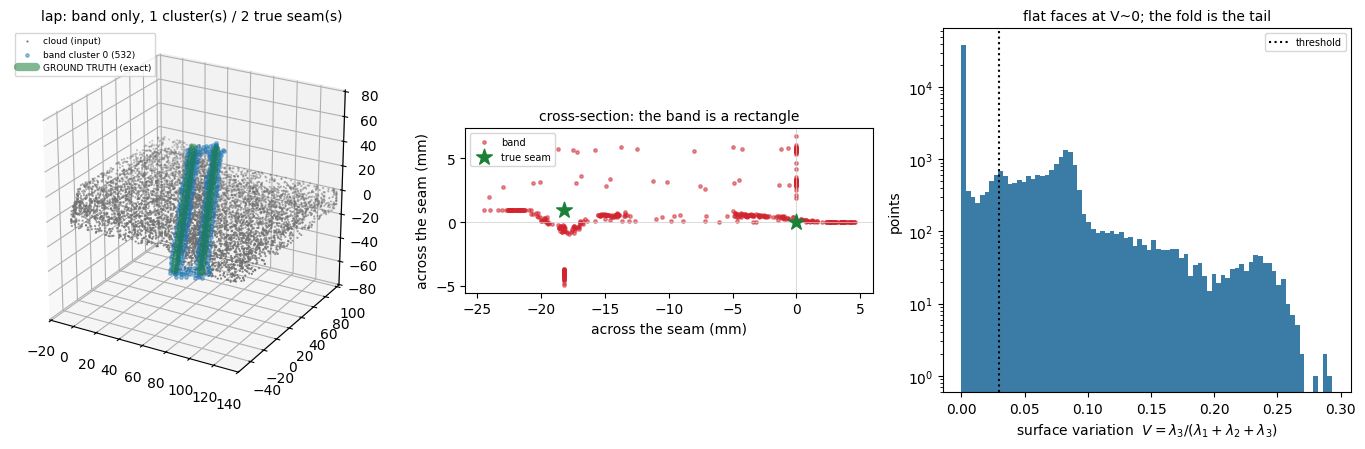

In [4]:
# --- knobs ---------------------------------------------------------------------------
ZOOM = 0.5        # 1.0 = whole assembly; 0.12 zooms right down onto the band
CENTRE = "seam"   # "seam" centres the view on the ground truth, "cloud" on the assembly
BAND_ALPHA = 0.45
COLOUR_BY = "cluster"   # "cluster" | "density"
ELEV, AZIM = 24, -60

# NO fitted line. The band and the truth, and nothing between them.
fig = plt.figure(figsize=(14, 4.6))

ax = fig.add_subplot(131, projection="3d")
pts = cloud["xyz"]
gt_pts = np.vstack(gt)
centre = gt_pts.mean(0) if CENTRE == "seam" else 0.5 * (pts.min(0) + pts.max(0))
span = float((pts.max(0) - pts.min(0)).max()) * float(ZOOM)
half = 0.55 * span
inside = np.all(np.abs(pts - centre) <= half, axis=1)
shown = pts[inside]
step = max(1, len(shown) // 7000)
ax.scatter(*shown[::step].T, s=0.3, c="#707070", label="cloud (input)")

if COLOUR_BY == "density" and len(res.band_raw):
    sc_ = ax.scatter(*res.band_raw.T, s=5, c=res.band_density, cmap="coolwarm",
                     vmin=0.4, vmax=1.4, alpha=BAND_ALPHA, depthshade=False)
    fig.colorbar(sc_, ax=ax, shrink=0.6, label="density / median")
else:
    for k in range(res.n_clusters):
        cl = res.clusters[k]
        ax.scatter(*cl.T, s=6, alpha=BAND_ALPHA, depthshade=False,
                   label=f"band cluster {k} ({len(cl)})" if k < 4 else None)
for k, g in enumerate(gt):
    ax.plot(*g.T, lw=6, c="#1a7f37", alpha=0.55, zorder=10, solid_capstyle="round",
            label="GROUND TRUTH (exact)" if k == 0 else None)

for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
    setter(centre[i] - half, centre[i] + half)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=ELEV, azim=AZIM)
ax.legend(fontsize=6.5, loc="upper left")
ax.set_title(f"{row['joint_type']}: band only, {res.n_clusters} cluster(s) / "
             f"{row['n_gt_seams']} true seam(s)", fontsize=10)

# The cross-section. This is where the "rectangle" is visible for what it is: the band is
# a slab straddling the joint, and any line fitted through it sits in the middle of the
# slab - the mid-surface between two plates, not on either seam.
ax2 = fig.add_subplot(132)
g0 = np.asarray(gt[0])
t = (g0[-1] - g0[0]); t /= np.linalg.norm(t)
tmp = np.array([0.0, 0.0, 1.0])
if abs(t @ tmp) > 0.9:
    tmp = np.array([1.0, 0.0, 0.0])
u = np.cross(t, tmp); u /= np.linalg.norm(u)
v = np.cross(t, u)
rel = res.band - g0[0]
ax2.scatter(rel @ u, rel @ v, s=6, c="#d1242f", alpha=0.5, label="band")
for k, g in enumerate(gt):
    rg = np.asarray(g) - g0[0]
    ax2.scatter((rg @ u).mean(), (rg @ v).mean(), s=140, marker="*", c="#1a7f37",
                zorder=5, label="true seam" if k == 0 else None)
ax2.axhline(0, c="#cccccc", lw=0.5); ax2.axvline(0, c="#cccccc", lw=0.5)
ax2.set_aspect("equal"); ax2.legend(fontsize=7)
ax2.set_xlabel("across the seam (mm)"); ax2.set_ylabel("across the seam (mm)")
ax2.set_title("cross-section: the band is a rectangle", fontsize=10)

ax3 = fig.add_subplot(133)
ax3.hist(res.variation, bins=80, color="#3a7ca5")
ax3.axvline(res.params["curvature_thresh"], c="k", ls=":", label="threshold")
ax3.set_yscale("log")
ax3.set_xlabel("surface variation  $V = \\lambda_3/(\\lambda_1+\\lambda_2+\\lambda_3)$")
ax3.set_ylabel("points")
ax3.legend(fontsize=7)
ax3.set_title("flat faces at V~0; the fold is the tail", fontsize=10)
plt.tight_layout(); plt.show()

## The validity window, on trial

Sweep `R` across and past the predicted window. If the claim holds, error should be poor
below `gap + spacing` (the ball never crosses the gap), acceptable inside, and degrade above
`thickness` (the ball bridges a plate's own two faces and everything looks like an edge).

This is plot 2 of Phase 4 for a single scene; the corpus version is what goes in the paper.

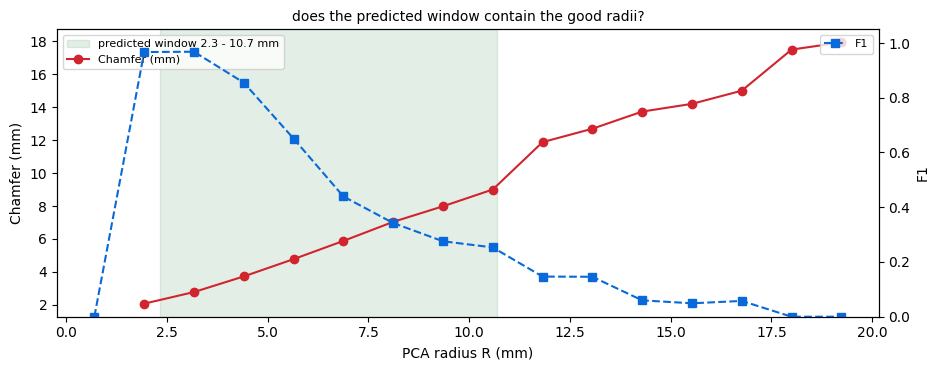

R giving within 90% of best F1: 1.93 - 3.17 mm
predicted window:               2.32 - 10.69 mm
-> they overlap by 0.85 mm


In [5]:
lo, hi = row["window_lo"], row["window_hi"]
radii = np.linspace(max(0.5, lo * 0.3), hi * 1.8, 16)
sweep = [run(DIRS[SCENE], radius_mm=float(R)) for R in radii]
chamfer = [o[0]["chamfer"] if o else np.nan for o in sweep]
f1 = [o[0]["f1"] if o else np.nan for o in sweep]

fig, axa = plt.subplots(figsize=(9.5, 3.8))
axa.axvspan(lo, hi, color="#1a7f37", alpha=0.12,
            label=f"predicted window {lo:.1f} - {hi:.1f} mm")
axa.plot(radii, chamfer, "o-", c="#d1242f", label="Chamfer (mm)")
axa.set_xlabel("PCA radius R (mm)"); axa.set_ylabel("Chamfer (mm)")
axb = axa.twinx(); axb.plot(radii, f1, "s--", c="#0969da", label="F1")
axb.set_ylabel("F1"); axb.set_ylim(0, 1.05)
axa.legend(loc="upper left", fontsize=8); axb.legend(loc="upper right", fontsize=8)
axa.set_title("does the predicted window contain the good radii?", fontsize=10)
plt.tight_layout(); plt.show()

# Read F1, not Chamfer. Chamfer is computed only where the method returned something, so
# it says nothing about the radii where it returned NOTHING - and those are exactly the
# failures the window predicts. On this scene it spans 5,9-6,7 mm across the whole sweep,
# i.e. it is flat noise, and "best R by Chamfer" would be reporting the argmin of noise.
f1a = np.asarray(f1, dtype=float)
good = radii[f1a >= 0.9 * np.nanmax(f1a)] if np.isfinite(f1a).any() else np.array([])
if len(good):
    print(f"R giving within 90% of best F1: {good.min():.2f} - {good.max():.2f} mm")
    print(f"predicted window:               {lo:.2f} - {hi:.2f} mm")
    overlap = min(good.max(), hi) - max(good.min(), lo)
    print("->", f"they overlap by {overlap:.2f} mm" if overlap > 0
          else "DISJOINT - the bound needs restating")
else:
    print("no radius produced a usable seam on this scene")

## The corpus

Full-visibility and single-view are evaluated **separately**, as the plan requires: a method
tuned on 360° CAD clouds is being flattered by geometry no camera returns.

Takes a couple of minutes.

In [6]:
rows = []
for d in DIRS:
    for view in ("full", "single"):
        o = run(d, view=view)
        if o:
            rows.append(o[0])
    del o
df = pd.DataFrame(rows)
print(f"{len(df)} runs over {df.scene_id.nunique()} scenes")
print(f"validity window CLOSED in {int((~df.window_open).sum())} of {len(df)} runs "
      f"- no valid R exists for those at rho = {RHO}")
df.head(3)[["joint_type", "view", "radius_mm", "chamfer", "f1", "cluster_count_error"]]

88 runs over 44 scenes
validity window CLOSED in 16 of 88 runs - no valid R exists for those at rho = 0.5


,joint_type,view,radius_mm,chamfer,f1,cluster_count_error
0,butt,full,4.983366,4.000987,0.873469,-1
1,butt,single,4.983366,3.789195,0.815094,0
2,edge,full,1.651132,84.637031,0.021268,11


In [7]:
cols = ["chamfer", "lat_p95", "precision", "recall", "f1", "band_width_mm",
        "cluster_count_error"]
print("median by view\n", df.groupby("view")[cols].median().round(3), "\n")
print("median by joint type\n",
      df.groupby(["joint_type", "view"])[cols].median().round(3))

median by view
         chamfer  lat_p95  precision  recall     f1  band_width_mm  \
view                                                                
full      4.027    3.898      0.623   1.000  0.762          5.085   
single    5.033    3.277      0.806   0.871  0.723          4.031   

        cluster_count_error  
view                         
full                   -1.0  
single                  0.0   

median by joint type
                    chamfer  lat_p95  precision  recall     f1  band_width_mm  \
joint_type view                                                                
T          full      3.710    3.982      0.586   1.000  0.735          4.885   
           single    5.435    3.584      0.806   0.871  0.660          3.946   
butt       full      4.001    4.023      0.651   1.000  0.789          5.001   
           single    4.758    3.650      0.654   0.875  0.681          4.276   
corner     full      3.589    3.051      0.923   1.000  0.956          4.325   
   

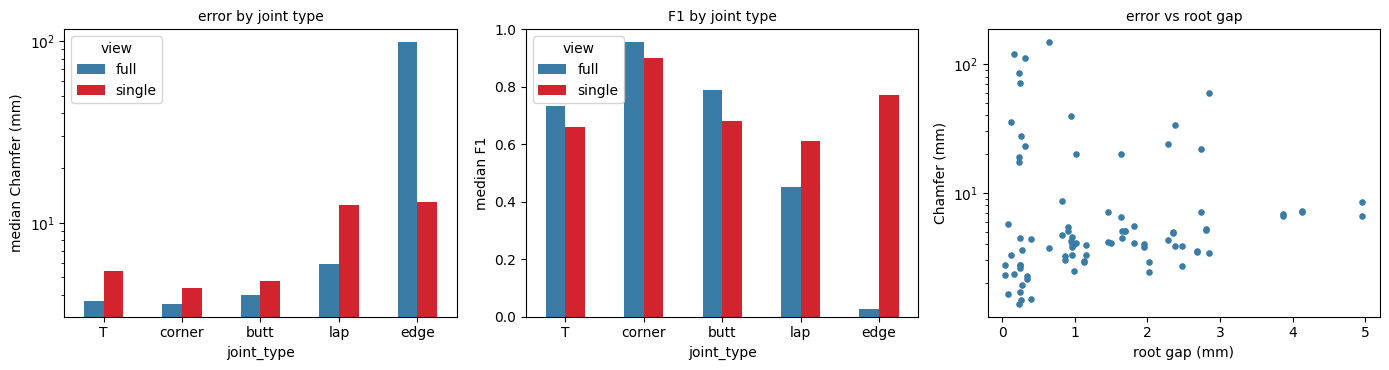

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
order = ["T", "corner", "butt", "lap", "edge"]
present = [j for j in order if j in set(df.joint_type)]

piv = df.pivot_table(index="joint_type", columns="view", values="chamfer",
                     aggfunc="median").reindex(present)
piv.plot.bar(ax=axes[0], color=["#3a7ca5", "#d1242f"], rot=0)
axes[0].set_ylabel("median Chamfer (mm)"); axes[0].set_yscale("log")
axes[0].set_title("error by joint type", fontsize=10)

df.pivot_table(index="joint_type", columns="view", values="f1",
               aggfunc="median").reindex(present).plot.bar(
    ax=axes[1], color=["#3a7ca5", "#d1242f"], rot=0)
axes[1].set_ylabel("median F1"); axes[1].set_ylim(0, 1)
axes[1].set_title("F1 by joint type", fontsize=10)

ok = df[np.isfinite(df.chamfer)]
axes[2].scatter(ok.root_gap_mm, ok.chamfer, s=14, c="#3a7ca5")
axes[2].set_xlabel("root gap (mm)"); axes[2].set_ylabel("Chamfer (mm)")
axes[2].set_yscale("log"); axes[2].set_title("error vs root gap", fontsize=10)
plt.tight_layout(); plt.show()

## Are the band's "false positives" actually false?

A lap overlap has **four** sides, and every one of them is a place where a plate edge meets
a plate face. The band finds all four. Ground truth calls two of them seams because
`accessibility._drop_cross_runs` decided the short ones are cross-runs — that is a
labelling **convention**, not geometry.

So scoring the band against the two declared seams charges it for finding something that is
really there. The generator keeps those other interfaces (`reject_reason: "too_short"`, or
off-class), so both scorings are available and the gap between them is the cost of the
convention rather than a property of the method.

In [9]:
rows_fp = []
for d in DIRS:
    o = run(d)
    if o is None:
        continue
    row_, res_, _, gt_, scene_ = o
    arrays_ = load_scene(d)[1]
    gt_all = ground_truth(scene_, arrays_, primary_only=False, include_rejected=True)
    if not gt_all:
        continue
    m_all = evaluate_band(res_.band, gt_all)
    rows_fp.append({"joint_type": row_["joint_type"],
                    "prec_declared": row_["precision"], "recall_declared": row_["recall"],
                    "prec_all": m_all["precision"], "recall_all": m_all["recall"],
                    "n_declared": row_["n_gt_seams"], "n_all": len(gt_all)})
fp = pd.DataFrame(rows_fp)
order = [j for j in ["T", "corner", "butt", "lap", "edge"] if j in set(fp.joint_type)]
print(fp.groupby("joint_type")[["n_declared", "n_all", "prec_declared", "prec_all",
                                "recall_declared", "recall_all"]].median()
      .reindex(order).round(3))

            n_declared  n_all  prec_declared  prec_all  recall_declared  \
joint_type                                                                
T                  2.0    4.0          0.586     0.603            1.000   
corner             2.0    2.0          0.923     0.923            1.000   
butt               2.0    8.0          0.651     0.840            1.000   
lap                2.0    4.0          0.293     0.317            0.987   
edge               1.0    6.0          0.014     0.052            1.000   

            recall_all  
joint_type              
T                1.000  
corner           1.000  
butt             1.000  
lap              0.988  
edge             1.000  


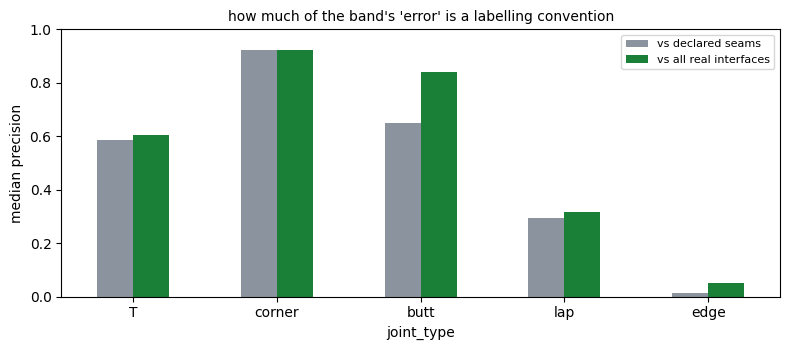

Recall is 1,00 under both scorings - the band always contains the seam.
Where the two precisions differ, the gap is the convention. Where they do not,
the lost precision is the band's WIDTH, which no relabelling fixes.


In [10]:
fig, ax = plt.subplots(figsize=(8, 3.6))
piv = fp.groupby("joint_type")[["prec_declared", "prec_all"]].median().reindex(order)
piv.plot.bar(ax=ax, color=["#8b949e", "#1a7f37"], rot=0)
ax.set_ylabel("median precision"); ax.set_ylim(0, 1)
ax.legend(["vs declared seams", "vs all real interfaces"], fontsize=8)
ax.set_title("how much of the band's 'error' is a labelling convention", fontsize=10)
plt.tight_layout(); plt.show()

print("Recall is 1,00 under both scorings - the band always contains the seam.")
print("Where the two precisions differ, the gap is the convention. Where they do not,")
print("the lost precision is the band's WIDTH, which no relabelling fixes.")

## The density anomaly on the raw band

A seam is not just a curvature feature. **Two surfaces converge at a fold, so a fold seam
sits in a density surplus; a coplanar seam is a gap in a flat surface, so it sits in a
deficit.** One measurement, and its *sign* says which family the seam belongs to.

The catch, and the reason this was invisible until now: `voxel_downsample` makes density
uniform by construction. Measured after the voxel merge the answer is 1,0 everywhere. So
`detect` now computes it on `band_raw` — the band *before* the merge — and carries it
alongside as `band_density`.

**Exposed, not yet acted on.** The detection path is unchanged; `band` is still
`voxel_downsample(band_raw, voxel_mm)` exactly as before. This cell is here to see whether
the signal is worth using before anything is built on it.

In [11]:
from baselines.metrics import distance_to_polylines

bins = [(0.0, 0.25), (0.25, 0.5), (0.5, 1.0), (1.0, 1.5), (1.5, 2.5)]
prof = {}
for d in DIRS:
    o = run(d)
    if o is None:
        continue
    r_, gt_, jt = o[1], o[3], o[0]["joint_type"]
    if not len(r_.band_raw):
        continue
    R = o[0]["radius_mm"]
    dg = distance_to_polylines(r_.band_raw, gt_)
    row_ = prof.setdefault(jt, {b: [] for b in bins})
    for b in bins:
        m = (dg >= b[0] * R) & (dg < b[1] * R)
        if m.any():
            row_[b].append(float(r_.band_density[m].mean()))

dens = pd.DataFrame(
    {f"{a}-{b}R": {jt: np.mean(v[(a, b)]) if v[(a, b)] else np.nan
                   for jt, v in prof.items()} for a, b in bins}
).reindex([j for j in ["T", "corner", "butt", "lap", "edge"] if j in prof])
print("local density / band median, vs distance from the true seam")
print(dens.round(2))

local density / band median, vs distance from the true seam
        0.0-0.25R  0.25-0.5R  0.5-1.0R  1.0-1.5R  1.5-2.5R
T            1.05       1.03      0.98      0.64       NaN
corner       1.26       1.10      0.85      0.47       NaN
butt         1.14       1.03      0.85      0.61       NaN
lap          1.16       1.09      0.88      0.97      0.81
edge         0.62       0.71      0.71      0.63      0.66


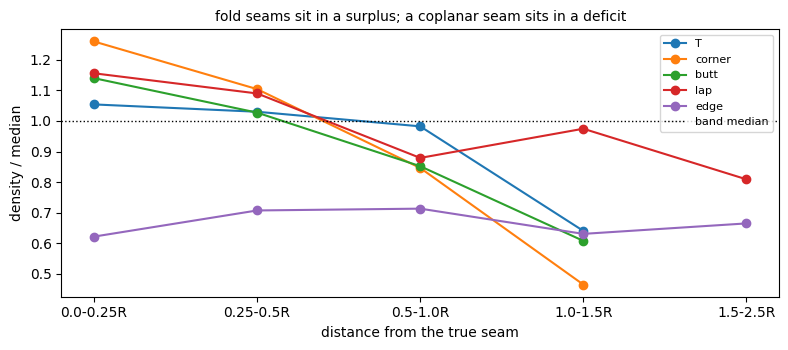

Read the SIGN, not just the magnitude: everything above 1,0 at the seam is a fold
(T, corner, butt, lap); edge sits below 1,0 because its seam is a gap, not a fold.


In [12]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(dens.columns))
for jt, r_ in dens.iterrows():
    ax.plot(x, r_.values, "o-", label=jt)
ax.axhline(1.0, c="k", ls=":", lw=1, label="band median")
ax.set_xticks(x); ax.set_xticklabels(dens.columns)
ax.set_xlabel("distance from the true seam"); ax.set_ylabel("density / median")
ax.legend(fontsize=8)
ax.set_title("fold seams sit in a surplus; a coplanar seam sits in a deficit", fontsize=10)
plt.tight_layout(); plt.show()

print("Read the SIGN, not just the magnitude: everything above 1,0 at the seam is a fold")
print("(T, corner, butt, lap); edge sits below 1,0 because its seam is a gap, not a fold.")

## The oracle ablation

`weld_require_cross_object` keeps an edge point only if a point of a **different object**
lies within `R`. It is what collapses the original's 266×211×134 mm blob to a line, and it
is not available at runtime: object membership comes from the registered CAD assembly.

So this is the honest point-cloud-only number, next to the published one. Any gap between
the two is the part of the method's performance that CAD registration is paying for.

In [13]:
abl = []
for d in DIRS[:20]:
    for oracle in (True, False):
        o = run(d, view="single", cross_object=oracle)
        if o:
            abl.append({**o[0], "arm": "CAD oracle" if oracle else "cloud only"})
abl = pd.DataFrame(abl)
print(abl.groupby("arm")[["chamfer", "precision", "recall", "f1",
                          "n_clusters"]].median().round(3))

            chamfer  precision  recall     f1  n_clusters
arm                                                      
CAD oracle    4.979      0.686   0.860  0.723         1.0
cloud only   46.390      0.263   0.982  0.395         1.0


## Open questions

1. **Act on the density anomaly.** It is weaker than `V` (a 1,05–1,26× surplus), so it
   belongs as a clustering weight or a tie-breaker, not as a detector. The specific target
   is the failure that causes every wrong seam count: sparse points *between* two seams
   bridge them into one component. Under DBSCAN with `eps` below the seam separation those
   become **noise** rather than bridges — but it has to run on the raw band, since the
   voxel merge is what erases the density difference.
2. **Coplanar seams are the same problem read backwards.** Edge joints and butt centrelines
   both sit in a density *deficit*. That unifies two cases previously treated separately.
3. **The CAD oracle is still doing most of the work** (F1 0,75 → 0,03 without it, below).
   Worth reporting as two arms rather than replacing: registered CAD is genuinely available
   in the deployed pipeline, so the honest questions are how much registration error
   propagates into the seam, and whether a cloud-only arm generalises to parts with no model.
4. **Is the predicted window the right window?** The usable-F1 range keeps coming out wider
   than `gap + spacing < R < thickness`.
5. **No noise yet.** Every run here is on the clean cloud; `run(..., noisy=True)` applies the
   analytic stereo model.